# 08c. 다중 임계값 성능 표 및 리드타임 심층 분석


In [23]:
import sys
import os
sys.path.insert(0, os.path.abspath('..'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import json
from pathlib import Path

import config.final_eval_config as cfg
from src.eval_core import (
    load_saved_ensemble, 
    prepare_disk_level_data, 
    evaluate_detailed_disk_point, 
    plot_detailed_disk_analysis
)

import matplotlib.font_manager as fm
def set_korean_font():
    for name in ["Malgun Gothic", "NanumGothic", "AppleGothic", "DejaVu Sans"]:
        if any(name.lower() in f.name.lower() for f in fm.fontManager.ttflist):
            plt.rcParams["font.family"] = name
            break
    plt.rcParams["axes.unicode_minus"] = False

set_korean_font()
print("✅ 환경 설정 및 라이브러리 로드 완료")

✅ 환경 설정 및 라이브러리 로드 완료


## 2. 테스트 데이터 및 예측 캐시 로드

In [24]:
print("🔄 최종 모델 및 최적 임계값 메타데이터 로드 중...")
artifacts = load_saved_ensemble(cfg, require_threshold=True)
BEST_T = 0.9590

print(f"🎯 운영점: 단일 임계값 T = {BEST_T:.4f}")

print("\n🔄 Test 데이터 로드 중...")
test_path = Path(cfg.TEST_PATH)
df_test = pd.read_parquet(test_path)
print(f"✅ 데이터 로드 완료: {len(df_test):,} 행 (파일: {test_path.name})")

cache_filename = f"{test_path.stem}_probs.npy"
cache_path = os.path.join(cfg.MODEL_SAVE_DIR, cache_filename)

if os.path.exists(cache_path):
    print(f"♻️ '{cache_filename}' 캐시된 예측 확률 파일 로드 중...")
    y_prob = np.load(cache_path)
    if len(y_prob) != len(df_test):
        raise ValueError("캐시 파일의 크기가 테스트 데이터와 일치하지 않습니다!")
    print(f"✅ 로드 완료: {len(y_prob):,}행")
else:
    raise FileNotFoundError("예측 확률 캐시 파일을 찾을 수 없습니다. 08b 노트북을 먼저 실행해주세요.")

print("\n🔄 시리얼별 정렬 및 디스크 단위 데이터 구성 중...")
disks_data, n_failed_disks, n_normal_disks = prepare_disk_level_data(
    df_test, y_prob, target_col=cfg.TARGET_COL, serial_col=cfg.SERIAL_COL, date_col=cfg.DATE_COL
)
print(f"✅ 총 {len(disks_data):,}개 디스크 구성 완료 (Failed: {n_failed_disks:,}, Normal: {n_normal_disks:,})")

stats_orig = evaluate_detailed_disk_point(
    disks_data, BEST_T, 1, n_failed_disks, n_normal_disks, window_size=0, horizon=30
)

🔄 최종 모델 및 최적 임계값 메타데이터 로드 중...

[Data Path Contract]
  [OK] model save directory: C:\Workspace\06_ML_projdect\26_1_COIN\models\underbagging_ensemble_4
  [OK] feature columns: C:\Workspace\06_ML_projdect\26_1_COIN\models\underbagging_ensemble_4\feature_cols.json (591 bytes)
  [OK] best threshold metadata: C:\Workspace\06_ML_projdect\26_1_COIN\models\underbagging_ensemble_4\best_threshold.json (679 bytes)
[Model Artifact Contract]
  model_dir: C:\Workspace\06_ML_projdect\26_1_COIN\models\underbagging_ensemble_4
  feature_cols: C:\Workspace\06_ML_projdect\26_1_COIN\models\underbagging_ensemble_4\feature_cols.json (27 features)
  threshold_path: C:\Workspace\06_ML_projdect\26_1_COIN\models\underbagging_ensemble_4\best_threshold.json
  threshold: 0.972027
  threshold_source_val_calib: C:\Workspace\06_ML_projdect\26_1_COIN\data\split_group_stratified\val_calib.parquet
  model: subset_00.pkl (9,539,044 bytes)
  model: subset_01.pkl (9,555,780 bytes)
  model: subset_02.pkl (9,557,204 bytes)
  

## 3. 다중 임계값 및 Horizon별 성능 비교
과거 모델에서 사용하던 Alarm Window 및 N-Condition 로직을 제거하고, 단일 알람(1-Condition) 정책 기반으로 4가지 주요 임계값(0.9820, 0.9720, 0.9590, 0.9401)에 대해 예측 기간(Horizon) 10일, 20일, 30일, 40일, 60일 기준의 성능 지표를 산출합니다.


In [25]:
import pandas as pd
import numpy as np
from src.eval_core import evaluate_detailed_disk_point

thresholds = [0.9820, 0.9720, 0.9590, 0.9401]
horizons = [10, 20, 30, 40, 60]

results = []

for t in thresholds:
    row = {'Threshold': f"{t:.4f}"}
    
    stats_30 = evaluate_detailed_disk_point(disks_data, t, 1, n_failed_disks, n_normal_disks, window_size=0, horizon=30)
    row['Disk FAR'] = f"{stats_30['far']*100:.2f} %"
    
    for h in horizons:
        stats = evaluate_detailed_disk_point(disks_data, t, 1, n_failed_disks, n_normal_disks, window_size=0, horizon=h)
        row[f'Disk Recall ({h}일)'] = f"{stats['recall']*100:.2f}%"
        row[f'Precision ({h}일)'] = f"{stats['precision']*100:.2f}%"
        
    results.append(row)

df_perf = pd.DataFrame(results)
columns_order = ['Threshold', 'Disk FAR', 'Disk Recall (10일)', 'Precision (10일)', 
                 'Disk Recall (20일)', 'Precision (20일)', 'Disk Recall (30일)', 'Precision (30일)', 'Disk Recall (40일)', 'Precision (40일)', 'Disk Recall (60일)', 'Precision (60일)']
df_perf = df_perf[columns_order]

from IPython.display import display, HTML
display(HTML("<h3>🚀 성능 평가 지표 (다중 임계값 x Horizon)</h3>"))
display(df_perf)


,Threshold,Disk FAR,Disk Recall (10일),Precision (10일),Disk Recall (20일),Precision (20일),Disk Recall (30일),Precision (30일),Disk Recall (40일),Precision (40일),Disk Recall (60일),Precision (60일)
0,0.9820,0.16 %,9.85%,91.74%,11.09%,92.59%,11.80%,93.01%,11.98%,93.10%,12.24%,93.24%
1,0.9720,0.46 %,14.02%,84.49%,17.30%,87.05%,19.08%,88.11%,19.96%,88.58%,20.50%,88.85%
2,0.9590,1.20 %,17.13%,72.01%,20.67%,75.65%,23.07%,77.61%,24.31%,78.51%,25.91%,79.56%
3,0.9401,1.98 %,17.57%,61.49%,22.89%,67.54%,26.00%,70.26%,27.42%,71.36%,29.99%,73.16%


## 4. 각 임계값별 전체 리드타임 심층 분석 (통합 테이블)
각 임계값(0.9820, 0.9720, 0.9590, 0.9401)에 대해, Horizon에 구애받지 않고 탐지된 전체
True Positive(고장 탐지 디스크)의 **리드타임(Lead Time)** 누적 탐지율 및 분포를 산출합니다.
이를 통해 전체 탐지된 디스크 중 특정 일수 이내에 탐지된 비율을 100%가 아닌 실제 비율로 확인할 수 있습니다.


In [26]:
from IPython.display import display, HTML
import pandas as pd
import numpy as np
from src.eval_core import evaluate_detailed_disk_point

results = []
days_thresholds = [0, 1, 3, 5, 7, 10, 14, 21, 30, 40, 60]

for t in thresholds:
    # 1. Calculate overall TPs for this threshold without horizon limits
    lead_times = []
    for d in disks_data:
        if d['is_failed'] == 1:
            probs = d['probs']
            alarms = (probs >= t).astype(int)
            idx = np.where(alarms >= 1)[0]
            if len(idx) > 0:
                lt = len(probs) - 1 - idx[0]
                lead_times.append(lt)
                
    lead_times = np.array(lead_times)
    total_failed = n_failed_disks
    total_tp = len(lead_times)
    
    # 2. Loop over thresholds and evaluate metrics
    for d_th in days_thresholds:
        # manual calculation for cumulative rates
        detected_within = np.sum(lead_times <= d_th)
        ratio_tp = (detected_within / total_tp * 100) if total_tp > 0 else 0.0
        
        # evaluate using the eval_core logic for consistent FAR, Recall, Precision
        stats = evaluate_detailed_disk_point(disks_data, t, 1, n_failed_disks, n_normal_disks, window_size=0, horizon=d_th)
        
        row = {
            'Threshold': f"{t:.4f}",
            '리드타임 구간': f"<= {d_th}일 전",
            '탐지 디스크 수': f"{detected_within:,}",
            '탐지 건(TP) 중 비율': f"{ratio_tp:.1f}%",
            '오탐율(FAR)': f"{stats['far']*100:.2f}%",
            '리콜(Recall)': f"{stats['recall']*100:.2f}%",
            '정밀도(Precision)': f"{stats['precision']*100:.2f}%"
        }
        results.append(row)

df_all = pd.DataFrame(results)

# display settings
pd.set_option('display.max_rows', None)
display(HTML("<h3>📊 통합 리드타임 및 성능 지표 테이블 (복붙용)</h3>"))
display(df_all)


,Threshold,리드타임 구간,탐지 디스크 수,탐지 건(TP) 중 비율,오탐율(FAR),리콜(Recall),정밀도(Precision)
0,0.9820,<= 0일 전,0,0.0%,0.16%,0.00%,0.00%
1,0.9820,<= 1일 전,33,20.4%,0.16%,2.93%,76.74%
2,0.9820,<= 3일 전,70,43.2%,0.16%,6.21%,87.50%
3,0.9820,<= 5일 전,89,54.9%,0.16%,7.90%,89.90%
4,0.9820,<= 7일 전,100,61.7%,0.16%,8.87%,90.91%
5,0.9820,<= 10일 전,111,68.5%,0.16%,9.85%,91.74%
6,0.9820,<= 14일 전,117,72.2%,0.16%,10.38%,92.13%
7,0.9820,<= 21일 전,125,77.2%,0.16%,11.09%,92.59%
8,0.9820,<= 30일 전,133,82.1%,0.16%,11.80%,93.01%
9,0.9820,<= 40일 전,136,84.0%,0.16%,11.98%,93.10%


## 5. 최적 운영점 (T=0.9590) 기준 구간별 리드타임 및 성능 지표 (전체 리드타임 포함)
최적 운영점 `T=0.9590`에서 탐지된 전체 고장 디스크(TP)를 기준으로 삼아, 30일 이내의 각 리드타임 구간별 누적 탐지율을 산출합니다.
맨 아래에 `전체 리드타임` 행을 추가하여, 30일 이하의 구간들이 100%가 아닌 전체 대비 실제 비율로 표현되도록 구성했습니다.
또한 오탐율(FAR), 리콜(Recall), 정밀도(Precision) 지표를 함께 테이블에 포함하여 출력합니다.


In [27]:
from IPython.display import display, HTML
import pandas as pd
import numpy as np
from src.eval_core import evaluate_detailed_disk_point

t_val = 0.9590
days_thresholds = [0, 1, 3, 5, 7, 10, 14, 21, 30, 60, 100]

# 1. Calculate overall TPs for T=0.9590 (overall lead times)
lead_times = []
for d in disks_data:
    if d['is_failed'] == 1:
        probs = d['probs']
        alarms = (probs >= t_val).astype(int)
        idx = np.where(alarms >= 1)[0]
        if len(idx) > 0:
            lt = len(probs) - 1 - idx[0]
            lead_times.append(lt)
            
lead_times = np.array(lead_times)
total_failed = n_failed_disks
total_tp = len(lead_times)

results = []

# 2. Loop through intervals up to 30 days
for d_th in days_thresholds:
    detected_within = np.sum(lead_times <= d_th)
    ratio_tp = (detected_within / total_tp * 100) if total_tp > 0 else 0.0
    
    # evaluate using the eval_core logic for FAR, Recall, Precision
    stats = evaluate_detailed_disk_point(disks_data, t_val, 1, n_failed_disks, n_normal_disks, window_size=0, horizon=d_th)
    
    row = {
        '리드타임 구간': f"<= {d_th}일 전",
        '탐지 디스크 수': f"{detected_within:,} 개",
        '탐지 건(TP) 중 비율': f"{ratio_tp:.2f}%",
        '오탐율(FAR)': f"{stats['far']*100:.2f}%",
        '리콜(Recall)': f"{stats['recall']*100:.2f}%",
        '정밀도(Precision)': f"{stats['precision']*100:.2f}%"
    }
    results.append(row)

# 3. Add '전체 리드타임' row
stats_overall = evaluate_detailed_disk_point(disks_data, t_val, 1, n_failed_disks, n_normal_disks, window_size=0, horizon=None)
row_overall = {
    '리드타임 구간': '전체 리드타임',
    '탐지 디스크 수': f"{total_tp:,} 개",
    '탐지 건(TP) 중 비율': '100.00%',
    '오탐율(FAR)': f"{stats_overall['far']*100:.2f}%",
    '리콜(Recall)': f"{stats_overall['recall']*100:.2f}%",
    '정밀도(Precision)': f"{stats_overall['precision']*100:.2f}%"
}
results.append(row_overall)

df_summary = pd.DataFrame(results)
display(HTML(f"<h3>🎯 운영점 T={t_val:.4f} 기준 구간별 리드타임 및 성능 지표 (전체 리드타임 포함)</h3>"))
display(df_summary)


,리드타임 구간,탐지 디스크 수,탐지 건(TP) 중 비율,오탐율(FAR),리콜(Recall),정밀도(Precision)
0,<= 0일 전,22 개,5.26%,1.20%,1.95%,22.68%
1,<= 1일 전,68 개,16.27%,1.20%,6.03%,47.55%
2,<= 3일 전,111 개,26.56%,1.20%,9.85%,59.68%
3,<= 5일 전,139 개,33.25%,1.20%,12.33%,64.95%
4,<= 7일 전,171 개,40.91%,1.20%,15.17%,69.51%
5,<= 10일 전,193 개,46.17%,1.20%,17.13%,72.01%
6,<= 14일 전,207 개,49.52%,1.20%,18.28%,73.31%
7,<= 21일 전,238 개,56.94%,1.20%,21.03%,75.96%
8,<= 30일 전,260 개,62.20%,1.20%,23.07%,77.61%
9,<= 60일 전,292 개,69.86%,1.20%,25.91%,79.56%


## 6. 오탐 분석의 다각화: 정상 개체 순수 오탐 vs 고장 개체 조기 오탐

현실적인 데이터 센터 환경에서 "정상 디스크" 역시 관측 기간 이후 결국 고장날 수 있으므로, 두 상태를 결정론적으로 이분하는 것은 분석의 한계를 낳을 수 있습니다. 
따라서 고장 디스크(`is_failed == 1`) 중 **유지보수 목표 기간(30일)보다 훨씬 이른 시점(> 30일 전)에 경보가 울린 조기 오탐(Early Alarm)**의 분포를 시각화하여 순수 오탐(정상 개체) 분포와 나란히 비교합니다.

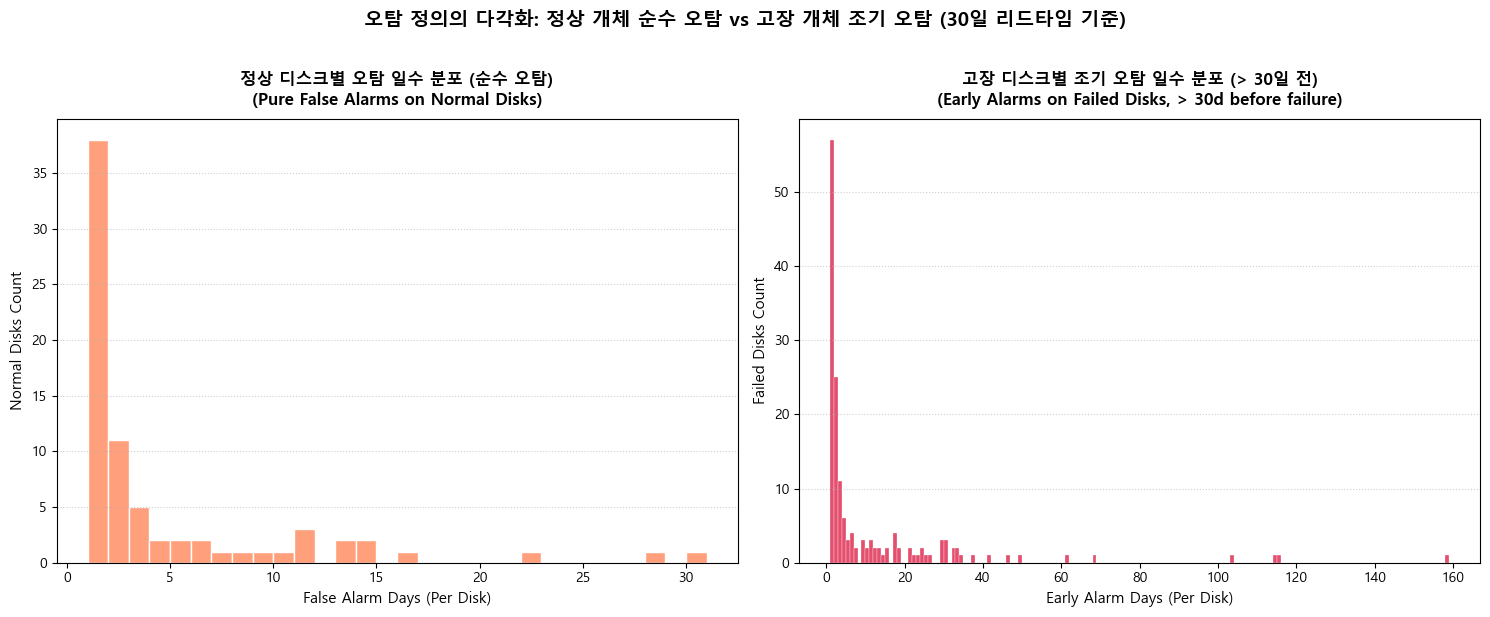

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

# 1. 0.9590 기준의 df_best_disk 구성 (노트북 독립성 보장)
t_val = 0.9590
best_disk_records = []
for disk in disks_data:
    probs = disk['probs']
    y_pred = (probs >= t_val).astype(int)
    total_alarms = y_pred.sum()
    
    lead_time = np.nan
    is_alarmed = 0
    
    if disk['is_failed'] == 1:
        dates = pd.Series(pd.to_datetime(disk['dates']))
        last_date = dates.iloc[-1]
        days_to_fail = (last_date - dates).dt.days
        
        # 고장 이전 모든 알람 중 첫 번째 알람의 Lead Time
        if y_pred.any():
            trigger_idx = np.where(y_pred == 1)[0][0]
            trigger_date = dates.iloc[trigger_idx]
            lead_time = (last_date - trigger_date).days
            is_alarmed = 1
    else:
        if y_pred.any():
            is_alarmed = 1
            
    best_disk_records.append({
        'base_serial': disk['base_serial'],
        'is_failed': disk['is_failed'],
        'is_alarmed': is_alarmed,
        'total_alarms': total_alarms,
        'lead_time': lead_time,
    })
    
df_best_disk_local = pd.DataFrame(best_disk_records)

# 2. 정상 디스크의 오탐 일수 (Pure False Alarms)
normal_fa_days = df_best_disk_local[(df_best_disk_local["is_failed"] == 0) & (df_best_disk_local["total_alarms"] > 0)]["total_alarms"]

# 3. 고장 디스크의 조기 오탐 일수 (>30일 전 알람 일수)
early_fa_days = []
for d in disks_data:
    if d['is_failed'] == 1:
        probs = d['probs']
        y_pred = (probs >= t_val).astype(int)
        dates = pd.Series(pd.to_datetime(d['dates']))
        last_date = dates.iloc[-1]
        days_to_fail = (last_date - dates).dt.days
        
        # 고장 30일 초과 전에 발생한 알람 일수 합산
        early_count = np.sum(y_pred[days_to_fail > 30])
        if early_count > 0:
            early_fa_days.append(early_count)

early_fa_days = pd.Series(early_fa_days)

# 4. 한국어 폰트 설정
import matplotlib.font_manager as fm
for name in ["Malgun Gothic", "NanumGothic", "AppleGothic", "DejaVu Sans"]:
    if any(name.lower() in f.name.lower() for f in fm.fontManager.ttflist):
        plt.rcParams["font.family"] = name
        break
plt.rcParams["axes.unicode_minus"] = False

# 5. 시각화: Side-by-Side 비교
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
fig.patch.set_facecolor('#ffffff')

# Left: 정상 디스크 오탐
sns.histplot(normal_fa_days, binwidth=1, kde=False, color="coral", edgecolor="white", ax=ax1)
ax1.set_title("정상 디스크별 오탐 일수 분포 (순수 오탐)\n(Pure False Alarms on Normal Disks)", fontsize=12, fontweight="bold", pad=10)
ax1.set_xlabel("False Alarm Days (Per Disk)", fontsize=11)
ax1.set_ylabel("Normal Disks Count", fontsize=11)
ax1.grid(axis="y", linestyle=":", alpha=0.6)

# Right: 고장 디스크 조기 오탐 (> 30일 전)
if len(early_fa_days) > 0:
    sns.histplot(early_fa_days, binwidth=1, kde=False, color="crimson", edgecolor="white", ax=ax2)
    ax2.set_title("고장 디스크별 조기 오탐 일수 분포 (> 30일 전)\n(Early Alarms on Failed Disks, > 30d before failure)", fontsize=12, fontweight="bold", pad=10)
    ax2.set_xlabel("Early Alarm Days (Per Disk)", fontsize=11)
    ax2.set_ylabel("Failed Disks Count", fontsize=11)
    ax2.grid(axis="y", linestyle=":", alpha=0.6)
else:
    ax2.text(0.5, 0.5, "조기 경보가 발생한 고장 개체가 없습니다.", ha="center", va="center", transform=ax2.transAxes)

plt.suptitle("오탐 정의의 다각화: 정상 개체 순수 오탐 vs 고장 개체 조기 오탐 (30일 리드타임 기준)", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()
